# 05 · Brightness and contrast with NumPy and OpenCV

Apply y = clip(round(0.75x + 20), 0, 255), compare pixel outputs, and measure the two implementations.

**Inputs:** two web photographs, [NASA astronaut](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut) and [coffee by Rachel Michetti](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee). Original files, source URLs, credits, and checksums are in [assets/](assets/). Both photographs are processed at their original dimensions.

**Group:** Nmertgules and Iliya.

The figures and measurements below are saved outputs from an actual execution. Use Restart Kernel and Run All to reproduce them.

## 1. Load and verify the photographs

The repository includes the images. If this notebook is opened alone in Colab, the same files are downloaded from the versioned URLs and checked against SHA-256 hashes.

In [1]:
%matplotlib inline
from pathlib import Path
from urllib.request import urlopen
import hashlib
import json
from time import perf_counter_ns

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
plt.rcParams.update({
    "figure.dpi": 95, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "figure.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False,
})
SOURCES = [{'name': 'astronaut', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'bytes': 791555, 'credit': 'NASA', 'license': 'Public domain', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut'}, {'name': 'coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'bytes': 466706, 'credit': 'Rachel Michetti, courtesy of Pikolo Espresso Bar', 'license': 'CC0 1.0', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee'}]
# Works from the repository root, from week2/, and in a standalone Colab notebook.
asset_dir = next((p for p in (Path("assets"), Path("week2/assets"))
                  if p.is_dir()), Path("assets"))
asset_dir.mkdir(parents=True, exist_ok=True)
images = {}
for source in SOURCES:
    path = asset_dir / (source["name"] + ".png")
    if not path.is_file():
        with urlopen(source["url"], timeout=45) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    assert hashlib.sha256(raw).hexdigest() == source["sha256"], f"Photo checksum mismatch: {path.name}"
    bgr = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot decode photograph: {path.name}")
    images[source["name"]] = {
        "rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY),
    }
    print(f"Loaded {source['name']}: {bgr.shape[1]} x {bgr.shape[0]} pixels; SHA-256 verified")

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def show_image(ax, image, title, vmax=255):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None,
              vmin=0 if image.ndim == 2 else None,
              vmax=vmax if image.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

def show_figure(fig):
    display(fig)
    plt.close(fig)

RESULTS = {}

Loaded astronaut: 512 x 512 pixels; SHA-256 verified
Loaded coffee: 600 x 400 pixels; SHA-256 verified


## 2. Method

NumPy calculates in float32, rounds to the nearest integer, and clips before converting to uint8. OpenCV convertScaleAbs also takes an absolute value: with uint8 input and these constants, 0.75x + 20 is always positive, so that extra step has no effect. A maximum difference of one intensity unit is allowed for platform rounding differences; the actual observed difference is reported. Timing uses warm-up, alternating order, and nine batches of 25 calls.

In [2]:
ALPHA, BETA = 0.75, 20.0
def numpy_transform(image):
    return np.clip(np.rint(image.astype(np.float32) * ALPHA + BETA), 0, 255).astype(np.uint8)

def opencv_transform(image):
    if min(BETA, ALPHA * 255 + BETA) < 0:
        raise ValueError("convertScaleAbs is not equivalent to clipping a negative affine result")
    return cv2.convertScaleAbs(image, alpha=ALPHA, beta=BETA)

def benchmark_pair(functions, batches=9, calls_per_batch=25):
    """Warm up, alternate measurement order, and report medians and IQRs."""
    samples = {name: [] for name in functions}
    for function in functions.values():
        for _ in range(3):
            function()
    names = list(functions)
    for batch in range(batches):
        for name in names[::1 if batch % 2 == 0 else -1]:
            start = perf_counter_ns()
            for _ in range(calls_per_batch):
                functions[name]()
            samples[name].append((perf_counter_ns() - start) / 1e6 / calls_per_batch)
    return {name: {
        "median_ms": float(np.median(values)),
        "q25_ms": float(np.percentile(values, 25)),
        "q75_ms": float(np.percentile(values, 75)),
        "batches": batches, "calls_per_batch": calls_per_batch,
    } for name, values in samples.items()}

## 3. Results on both photographs

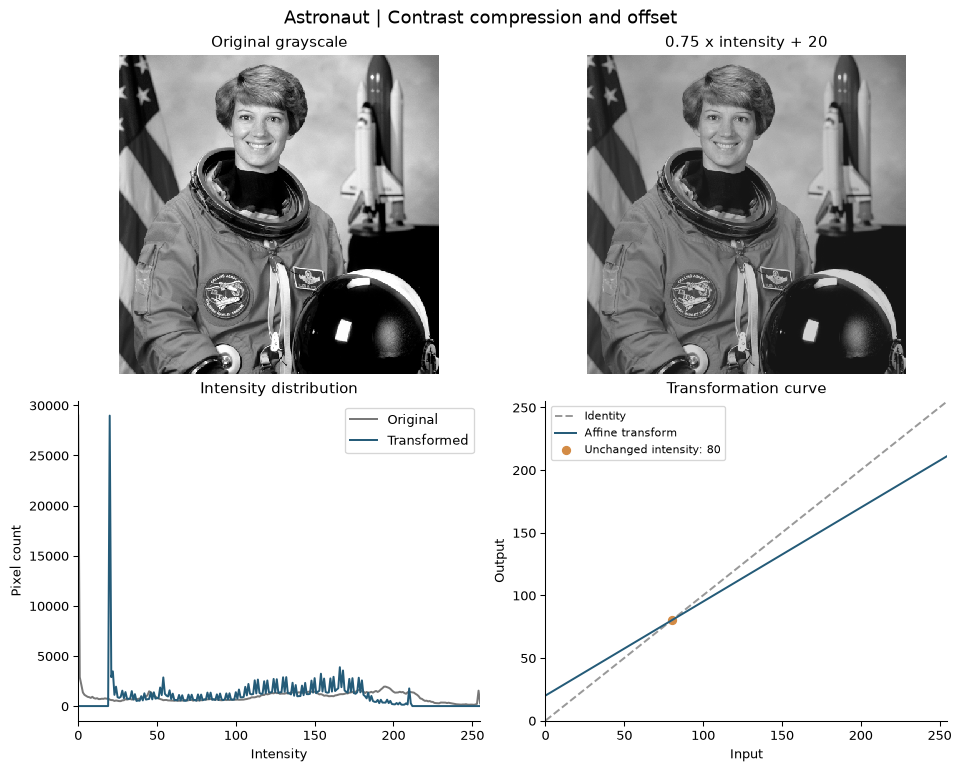

| Method | Median (ms) | IQR (ms) |
| --- | --- | --- |
| NumPy | 1.5220 | 1.5023 to 1.6283 |
| OpenCV | 0.0395 | 0.0360 to 0.0412 |

Max NumPy/OpenCV pixel difference: 0; mean intensity: 115.405 -> 106.556


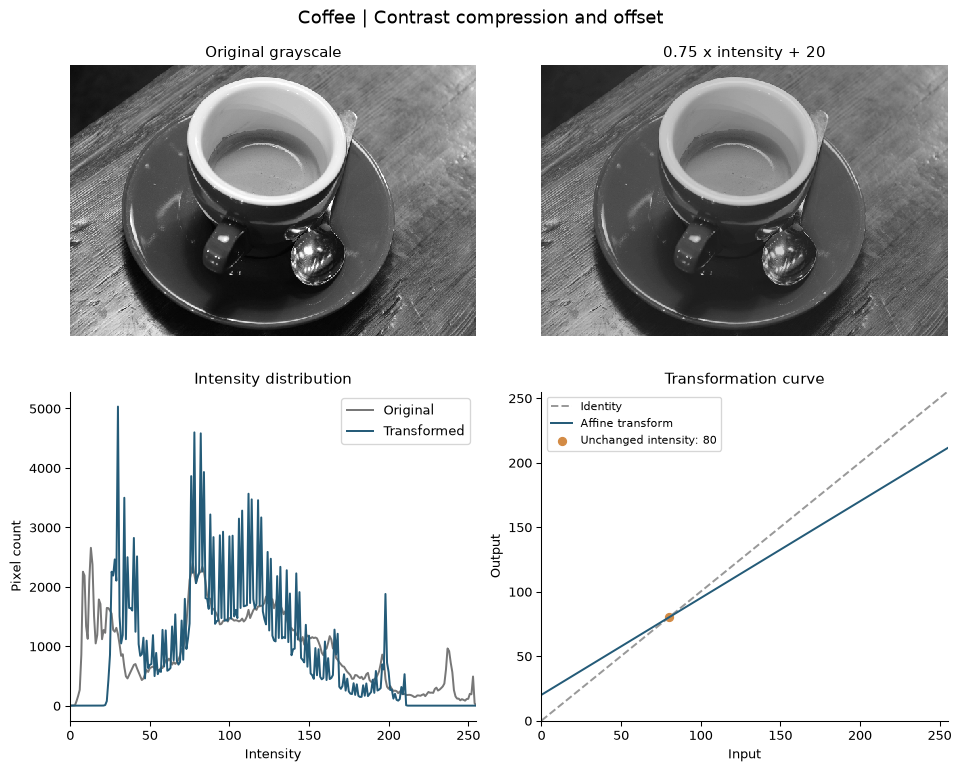

| Method | Median (ms) | IQR (ms) |
| --- | --- | --- |
| NumPy | 0.8840 | 0.8785 to 0.9025 |
| OpenCV | 0.0369 | 0.0361 to 0.0376 |

Max NumPy/OpenCV pixel difference: 0; mean intensity: 103.652 -> 97.741


In [3]:
for name, photo in images.items():
    image = photo["gray"]
    result = numpy_transform(image)
    cv_result = opencv_transform(image)
    difference = np.abs(result.astype(np.int16) - cv_result.astype(np.int16))
    assert result.dtype == cv_result.dtype == np.uint8
    assert result.shape == image.shape and difference.max() <= 1
    timings = benchmark_pair({"NumPy": lambda: numpy_transform(image), "OpenCV": lambda: opencv_transform(image)})
    fig, axes = plt.subplots(2, 2, figsize=(10, 8), layout="constrained")
    show_image(axes[0, 0], image, "Original grayscale")
    show_image(axes[0, 1], result, "0.75 x intensity + 20")
    x = np.arange(256)
    axes[1, 0].plot(x, np.bincount(image.ravel(), minlength=256), color="#777777", label="Original")
    axes[1, 0].plot(x, np.bincount(result.ravel(), minlength=256), color="#245b78", label="Transformed")
    axes[1, 0].set(xlabel="Intensity", ylabel="Pixel count", title="Intensity distribution", xlim=(0, 255))
    axes[1, 0].legend()
    axes[1, 1].plot(x, x, "--", color="#999999", label="Identity")
    axes[1, 1].plot(x, ALPHA * x + BETA, color="#245b78", label="Affine transform")
    axes[1, 1].scatter([80], [80], color="#d38b45", label="Unchanged intensity: 80")
    axes[1, 1].set(xlim=(0, 255), ylim=(0, 255), xlabel="Input", ylabel="Output", title="Transformation curve")
    axes[1, 1].legend(fontsize=8)
    fig.suptitle(name.title() + " | Contrast compression and offset", fontsize=14)
    show_figure(fig)
    show_table(["Method", "Median (ms)", "IQR (ms)"], [[k, f"{v['median_ms']:.4f}", f"{v['q25_ms']:.4f} to {v['q75_ms']:.4f}"] for k, v in timings.items()])
    print(f"Max NumPy/OpenCV pixel difference: {difference.max()}; mean intensity: {image.mean():.3f} -> {result.mean():.3f}")
    RESULTS[name] = {"max_pixel_difference": int(difference.max()), "mean_before": float(image.mean()), "mean_after": float(result.mean()), "output_min": int(result.min()), "output_max": int(result.max()), "timings": timings}

## 4. Interpretation

The additive offset lifts black to 20, but the multiplier compresses contrast. Before rounding, intensities below 80 brighten and intensities above 80 darken. Therefore the mean intensity can decrease even though the offset is positive. OpenCV performance here reflects this operation and this machine; it is not a general claim about every image-processing algorithm.

In [4]:
ramp = np.arange(256, dtype=np.uint8).reshape(16, 16)
difference = np.abs(numpy_transform(ramp).astype(np.int16) - opencv_transform(ramp).astype(np.int16))
assert difference.max() <= 1
assert numpy_transform(np.array([0, 80, 255], dtype=np.uint8)).tolist() == [20, 80, 211]
print(f"PASS: both photos, all 256 possible intensities, and endpoints. Ramp max difference: {difference.max()}.")

PASS: both photos, all 256 possible intensities, and endpoints. Ramp max difference: 0.
